## The irreducible mass of black holes.

For a BH of mass $M$ spin $\chi\in [0,1]$, the irreducible mass is 

$$\begin{equation}
    M_{\rm irr} = %\sqrt{\frac{M^2+\sqrt{M^4-S^2}}{2}} = 
     M \sqrt{\frac{1+\sqrt{1-\chi^2}}{2}}
\end{equation}$$

For convenience, let us define 

$$f(\chi) = \sqrt{\frac{1+\sqrt{1-\chi^2}}{2}} = M_{\rm irr} / M$$

Suppose you have repeated measurments of $M$ and $\chi$. This is just because we're still frequentists for now. When we will put our Bayesian hat on, these distributions will be the *posterior samples* from a single measurement.

Let's assume that

- the spin $\chi$ is uniformly distributed between 0 and 1.
- the mass $M$ is normally distributed with mean $\mu$ and standard deviation $\sigma$.
- (masses and spins are uncorrelated)

These are simplistic assumption that, however, are not too far from what we are now measuring with gravitational-wave detectors. It's a toy model, but not a totally unreasonable one.

**Tasks**:

1. Start with a value of $\sigma=0.02$. Note that $\mu$ is a scale and not a parameter: you can normalize all quantities with a dimension of mass by $\mu$. Just set $\mu=1$ in your code and remember that all masses in the problem are measured in units of $\mu$. 

2. Plot the resulting pdf of $M_{\rm irr}$. First try an histogram with one the rules of thumb we've seen above.

*Hint (for point 2)*: You don't know the functional form of the pdf of $M_{\rm irr}$... but you don't need it if you just want to generate samples! That's the nice thing about numerics!

3. Using the same samples, plot the distribution of $M_{\rm irr}$ using a KDE.

4. Compute the KS distance between ${M_{\rm irr}}/\mu$ and ${f}$ as a function of $\sigma$. Discuss the limits at large and small values of $\sigma$. 

5. Compute the KS distance between ${M_{\rm irr}}$ and $M$ as a function of $\sigma$. Discuss the limits at large and small values of $\sigma$.

*Hint (for points 4 and 5)*. This is a KS test between two sets for samples, `scipy.stats.ks_2samp`.

You should find that (i) $M_{\rm irr}$ is distributed like $f$ if ${\sigma}\ll \mu$ and (ii) $M_{\rm irr}$ is distributed like $M$ if  $\sigma\gg \mu$.

In [2]:
import numpy as np
from matplotlib import pyplot as plt
from scipy.stats import norm, uniform
from scipy import stats
from sklearn.neighbors import KernelDensity
import astropy.visualization.hist


In [3]:
N = 10000
chi = uniform.rvs(0, 1, N)
f = np.sqrt((1+np.sqrt(1-chi**2))/2)

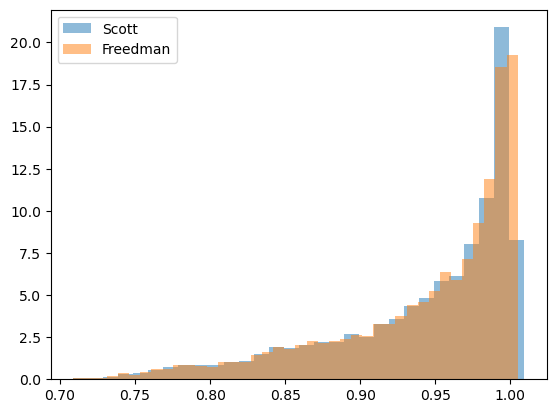

In [4]:
astropy.visualization.hist(f, bins='scott',density=True, alpha=0.5, label='Scott')
astropy.visualization.hist(f, bins='freedman', density=True, alpha=0.5, label='Freedman')
plt.legend()

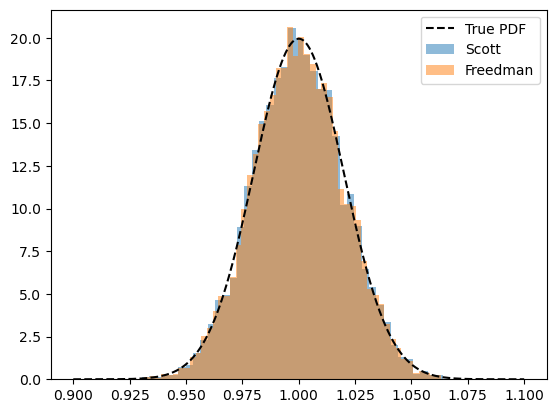

In [7]:
mu = 1
sigma = 0.02

mass = norm.rvs(mu, sigma, N)
x_grid = np.linspace(mu-5*sigma, mu+5*sigma, N)
true_pdf =  norm.pdf(x_grid, mu, sigma)

plt.plot(x_grid, true_pdf, '--k', label='True PDF')
astropy.visualization.hist(mass, bins='scott', density=True, alpha=0.5, label='Scott')
astropy.visualization.hist(mass, bins='freedman', density=True, alpha=0.5, label='Freedman')
plt.legend()

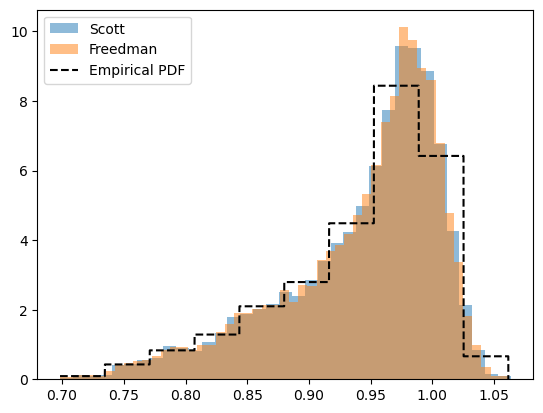

In [8]:
M_irr = f*mass

M_irr_hist = np.histogram(M_irr, density=True)
M_irr_pdf = stats.rv_histogram(M_irr_hist)

x_grid = np.linspace(M_irr.min(), M_irr.max(), N)

astropy.visualization.hist(M_irr, bins='scott', density=True, alpha=0.5, label='Scott')
astropy.visualization.hist(M_irr, bins='freedman', density=True, alpha=0.5, label='Freedman')
plt.plot(x_grid, M_irr_pdf.pdf(x_grid), '--k', label='Empirical PDF')
plt.legend()


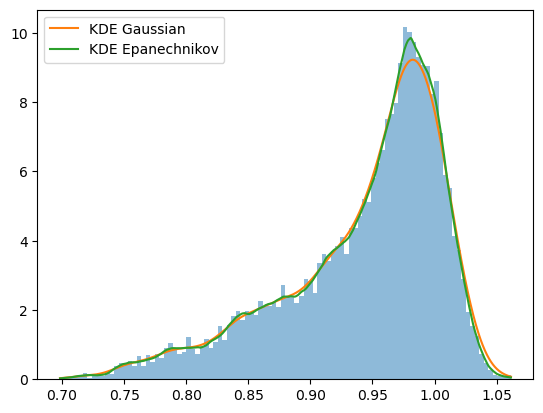

In [9]:
# Using a KDE
def kde (data, bandwidth=1.0, kernel='linear'):
    kde_skl = KernelDensity(bandwidth=bandwidth, kernel=kernel)
    kde_skl.fit(data[:, np.newaxis])
    log_pdf = kde_skl.score_samples((x_grid[:, np.newaxis]))
    return np.exp(log_pdf)

M_irr_kde_gauss = kde(M_irr, bandwidth=0.01, kernel='gaussian')
M_irr_kde_epan = kde(M_irr, bandwidth=0.01, kernel='epanechnikov')
plt.plot(x_grid, M_irr_kde_gauss, label='KDE Gaussian' , color='C1')
plt.plot(x_grid, M_irr_kde_epan, label='KDE Epanechnikov', color='C2')
plt.hist(M_irr, bins=100, density=True, alpha=0.5, color='C0')
plt.legend()


#### Points 4 and 5

In [10]:
def M_irr(sigma):
    mass = np.random.normal(mu, sigma, N)
    chi = np.random.uniform(0, 1, N)
    f = np.sqrt((1+np.sqrt(1-chi**2))/2)
    M_irr = mass*f
    return M_irr

small_M_irr = M_irr(0.001)
big_M_irr = M_irr(0.1)

(array([3.39633571e-02, 3.39633571e-02, 2.03780142e-01, 1.69816785e-01,
        2.37743499e-01, 2.03780142e-01, 3.39633571e-01, 6.79267141e-02,
        3.39633571e-01, 3.39633571e-01, 2.71706857e-01, 4.07560285e-01,
        4.41523642e-01, 4.75486999e-01, 3.05670214e-01, 5.43413713e-01,
        3.05670214e-01, 3.73596928e-01, 6.45303784e-01, 5.77377070e-01,
        6.79267141e-01, 5.43413713e-01, 7.13230498e-01, 7.13230498e-01,
        6.45303784e-01, 6.79267141e-01, 7.81157213e-01, 7.81157213e-01,
        1.15475414e+00, 7.47193855e-01, 8.49083927e-01, 7.47193855e-01,
        1.08682743e+00, 1.08682743e+00, 8.83047284e-01, 9.50973998e-01,
        1.42646100e+00, 8.15120570e-01, 1.15475414e+00, 1.29060757e+00,
        1.59627778e+00, 1.22268085e+00, 1.25664421e+00, 1.59627778e+00,
        1.46042435e+00, 1.66420450e+00, 1.56231443e+00, 1.76609457e+00,
        1.69816785e+00, 1.93591135e+00, 1.66420450e+00, 1.52835107e+00,
        1.80005792e+00, 1.46042435e+00, 2.27554492e+00, 2.207618

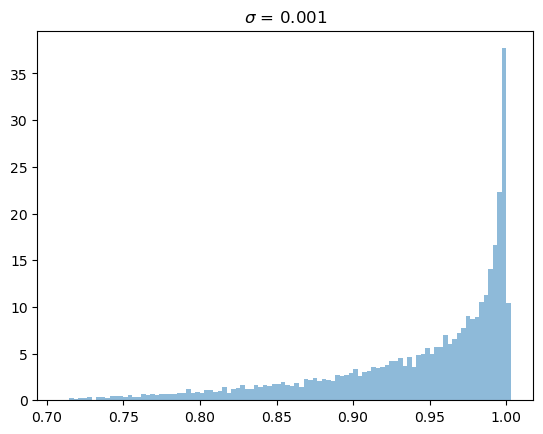

In [13]:
plt.title(r'$\sigma$ = 0.001')
plt.hist(small_M_irr, bins = 100, density = True, alpha=0.5)

(array([0.01173129, 0.        , 0.        , 0.        , 0.        ,
        0.03519386, 0.01173129, 0.        , 0.02346257, 0.01173129,
        0.03519386, 0.04692515, 0.04692515, 0.05865644, 0.11731287,
        0.10558159, 0.16423802, 0.19943189, 0.1877006 , 0.25808832,
        0.35193862, 0.35193862, 0.49271407, 0.52790793, 0.48098278,
        0.91504042, 0.93850299, 0.98542814, 0.90330913, 1.2083226 ,
        1.2083226 , 1.29044161, 1.2083226 , 1.6775741 , 1.94739371,
        1.81834954, 2.00605014, 2.29933233, 2.15855688, 2.19375074,
        2.18201945, 2.5104955 , 2.87416541, 2.94455313, 3.00320957,
        2.87416541, 3.19091017, 3.66016166, 3.4372672 , 3.60150523,
        3.4372672 , 3.54284879, 3.55458008, 3.29649175, 3.69535552,
        2.85070283, 3.15571631, 3.07359729, 3.22610403, 2.7920464 ,
        3.02667214, 2.62780837, 2.47530164, 2.46357035, 1.91219984,
        2.12336302, 1.65411152, 1.63064895, 1.74796182, 1.26697904,
        0.99715943, 1.05581586, 0.87984655, 0.73

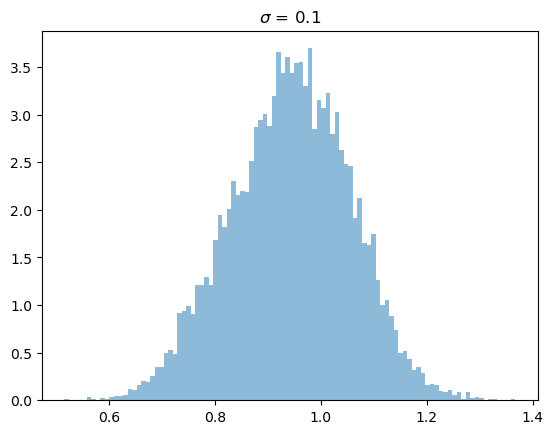

In [14]:
plt.title(r'$\sigma$ = 0.1')
plt.hist(big_M_irr, bins = 100, density = True, alpha=0.5)

In [17]:
N_sigma = 10
sigmas = np.linspace(0.001, 15, N_sigma)
KS_irr = []
KS_m = []

chi = np.random.uniform(0, 1, N)
f = np.sqrt((1+np.sqrt(1-chi**2))/2)

for sigma in sigmas:
    mass = np.random.normal(mu, sigma, N)
    KS_irr.append(stats.ks_2samp(mass, mass*f))
    KS_m.append(stats.ks_2samp(f, mass*f))

KS_irr = np.array(KS_irr)
KS_m = np.array(KSm)

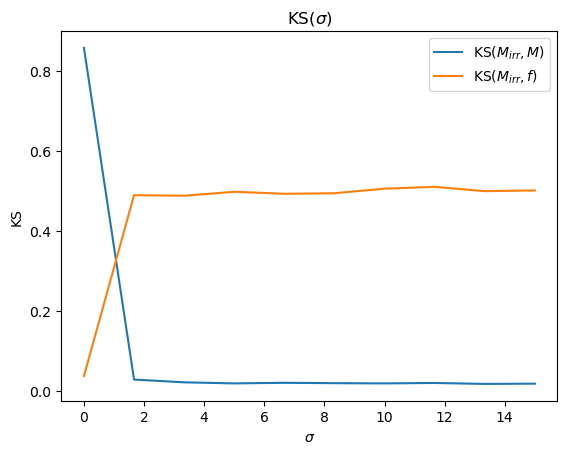

In [18]:
plt.plot(sigmas, KS_irr[:,0], label = r'KS($M_{irr}, M$)')
plt.plot(sigmas, KS_m[:,0], label = r'KS($M_{irr}, f$)')
plt.xlabel(r'$\sigma$')
plt.ylabel('KS')
plt.title(r'KS($\sigma$)')
plt.legend()